# Safety evolution

Safety as a trajectory over time instead of a single final mean. A small final
Exp1->Exp7 gap can hide an early divergence or a slow accumulation, and the
mean hides who is unsafe. Plots:

1. Fleet mean safety vs time, one line per algorithm, faceted by R. The band is
   the spread across the four behaviour/ic combos.
2. Replicate band at the focus setup (d=258, R=0.5, go_back, home) with K=11
   runs per algorithm.
3. Safety gap trajectory `safety_k(t) - safety_exp1(t)` with Exp7 as the
   ceiling. Shows when the divergence happens.
4. Per-taxi safety p10/p50/p90 ribbon over time, the inequality dynamics.
5. Per-region trajectories in the imbalanced city, hotspot vs periphery.
6. Shift and break overlay. Reset cohorts re-home every 8h shift, which resets
   the curves.

Curves that separate beyond their bands and stay separated are robust. Curves
that cross or converge mean the final mean difference is not meaningful.
Trajectories are not tested per timestamp because successive batches are
autocorrelated.


In [1]:
from pathlib import Path

# Switch geometry and re-run to compare layouts (separate figures per geometry).
GEOMETRY = 'imbalanced'        # 'balanced' or 'imbalanced'
D_FOCUS = 258                  # fleet size the trajectories are loaded at
FOCUS_R = 0.5                  # operating point R for the focus / ribbon views

# 1 TU = 10 s; an 8h shift = 2880 TU, a 24h day = 8640 TU. Reset cohorts re-home
# at each shift boundary, which shows up as resets in the curves.
SHIFT_TU = 2880
DAY_TU = 8640

CACHE_DIR = Path('.') / 'cache'
FORCE_RECOMPUTE = False        # True rebuilds the trajectory pickle from the .gz files

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from exp_utils import load_safety_trajectories, exp_label, apply_pub_style, legend_outside

apply_pub_style()

## Load trajectories

In [ ]:
fleet = load_safety_trajectories(GEOMETRY, agg='fleet', d_focus=D_FOCUS,
                                 include_reps=True, force=FORCE_RECOMPUTE)
region = load_safety_trajectories(GEOMETRY, agg='region', d_focus=D_FOCUS,
                                  include_reps=True, force=FORCE_RECOMPUTE)
if fleet.empty:
    raise RuntimeError(f'No fleet trajectories for {GEOMETRY!r}. '
                       f'Build the cache: load_safety_trajectories(..., force=True).')

EXPERIMENTS = sorted(fleet['experiment'].unique())
EXP_ALGO = (fleet.drop_duplicates('experiment')
            .set_index('experiment')['algorithm'].to_dict())
EXP_LABEL = {e: exp_label(e, EXP_ALGO[e]) for e in EXPERIMENTS}
_cmap = plt.get_cmap('tab10')
EXP_COLOR = {e: _cmap(i % 10) for i, e in enumerate(EXPERIMENTS)}
R_VALS = sorted(fleet['R'].dropna().unique())

print(f'Geometry    : {GEOMETRY}  (d={D_FOCUS})')
print(f'Experiments : {EXPERIMENTS}')
print(f'R values    : {R_VALS}')
print(f'Batches     : {fleet["timestamp"].nunique()} '
      f'(step {int(np.diff(sorted(fleet["timestamp"].unique()))[0])} TU, '
      f'to {int(fleet["timestamp"].max())} TU)')
print(f'Region data : {sorted(region["experiment"].unique()) if not region.empty else "none"}')


def _nonrep(df):
    return df[~df['is_rep'].astype(bool)] if 'is_rep' in df.columns else df


def run_band(sub, col='safety_mean'):
    """Mean line and min/max spread across the runs present at each timestamp."""
    g = sub.groupby('timestamp')[col]
    return pd.DataFrame({'timestamp': list(g.groups.keys()),
                         'mean': g.mean().to_numpy(),
                         'lo': g.min().to_numpy(),
                         'hi': g.max().to_numpy()}).sort_values('timestamp')


def focus_runs(df, exp):
    """All K replicates at the focus point (the x1 run plus its _rep copies)."""
    return df[(df['experiment'] == exp) & (df['R'] == FOCUS_R) &
              (df['behaviour'] == 'go_back') &
              (df['initial_conditions'] == 'home')]

## 1. Fleet mean safety vs time, faceted by R

One line per algorithm. The shaded band is the spread across the four
behaviour/ic combos, with replicates excluded so the band is comparable at
every R. A gap that opens early and plateaus is an ordering effect, one that
keeps growing is sorting.


In [ ]:
base = _nonrep(fleet)
fig, axes = plt.subplots(1, len(R_VALS), figsize=(3.7 * len(R_VALS), 3.8),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, R in zip(axes, R_VALS):
    for e in EXPERIMENTS:
        sub = base[(base['experiment'] == e) & (base['R'] == R)]
        if sub.empty:
            continue
        b = run_band(sub)
        ax.plot(b['timestamp'], b['mean'], color=EXP_COLOR[e], lw=1.6,
                label=EXP_LABEL[e])
        ax.fill_between(b['timestamp'], b['lo'], b['hi'], color=EXP_COLOR[e],
                        alpha=0.12, linewidth=0)
    ax.set_title(f'R = {R}')
    ax.set_xlabel('time (TU)')
axes[0].set_ylabel('fleet-mean safety score')
fig.suptitle(f'Fleet-mean safety over time - {GEOMETRY} (band = across behaviours)')
fig.tight_layout()
legend_outside(fig, ax=axes[0])
plt.show()

## 2. Replicate band at the focus setup

The focus point (d=258, R=0.5, go_back, home) replicated K=11 times per algorithm.
A tight band that is clearly separated between algorithms is the visual analogue of
the replicate test in the other cross-experiment notebooks.

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for e in EXPERIMENTS:
    sub = focus_runs(fleet, e)
    if sub.empty:
        continue
    b = run_band(sub)
    ax.plot(b['timestamp'], b['mean'], color=EXP_COLOR[e], lw=1.8, label=EXP_LABEL[e])
    ax.fill_between(b['timestamp'], b['lo'], b['hi'], color=EXP_COLOR[e],
                    alpha=0.15, linewidth=0)
ax.set_xlabel('time (TU)', fontsize=14)
ax.set_ylabel('fleet-mean safety score', fontsize=14)
ax.set_title(f'd={D_FOCUS}, R={FOCUS_R}, go_back, home - {GEOMETRY}', fontsize=14)
ax.tick_params(labelsize=12)
# Legend kept inside (top-right) only for this plot: the bands decay leftward over
# the run so the upper-right corner is free, and the side-by-side thesis layout has
# no room for an external legend.
ax.legend(loc='upper right', fontsize=11, frameon=True, framealpha=0.9)
fig.tight_layout()
plt.show()

## 3. Safety gap trajectory vs Exp1, faceted by R

`safety_k(t) - safety_exp1(t)`, averaged over behaviours. Exp1 is the zero
line. A small final gap can still reveal an early, sustained divergence here.


In [ ]:
def mean_curve(df, exp, R):
    sub = _nonrep(df)
    sub = sub[(sub['experiment'] == exp) & (sub['R'] == R)]
    if sub.empty:
        return None
    g = sub.groupby('timestamp')['safety_mean'].mean()
    return g

fig, axes = plt.subplots(1, len(R_VALS), figsize=(3.7 * len(R_VALS), 3.8),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, R in zip(axes, R_VALS):
    ref = mean_curve(fleet, 'exp1', R)
    if ref is None:
        ax.set_title(f'R = {R} (no exp1)')
        continue
    for e in EXPERIMENTS:
        if e == 'exp1':
            continue
        cur = mean_curve(fleet, e, R)
        if cur is None:
            continue
        gap = (cur - ref).reindex(ref.index)
        lw = 1.3
        ax.plot(gap.index, gap.to_numpy(), color=EXP_COLOR[e], lw=lw,
                label=EXP_LABEL[e])
    ax.axhline(0, color='black', lw=1.0, ls='--', alpha=0.6)
    ax.set_title(f'R = {R}')
    ax.set_xlabel('time (TU)')
axes[0].set_ylabel('safety gap vs Exp1')
fig.suptitle(f'Safety-gap trajectory (algorithm - Exp1) - {GEOMETRY}')
fig.tight_layout()
legend_outside(fig, ax=axes[0])
plt.show()

## 4. Per-taxi safety distribution ribbon (p10 / p50 / p90)

At the focus R, the within-fleet safety spread over time, averaged across the K
replicates. A widening p10-p90 ribbon means growing inequality even if the median
holds.

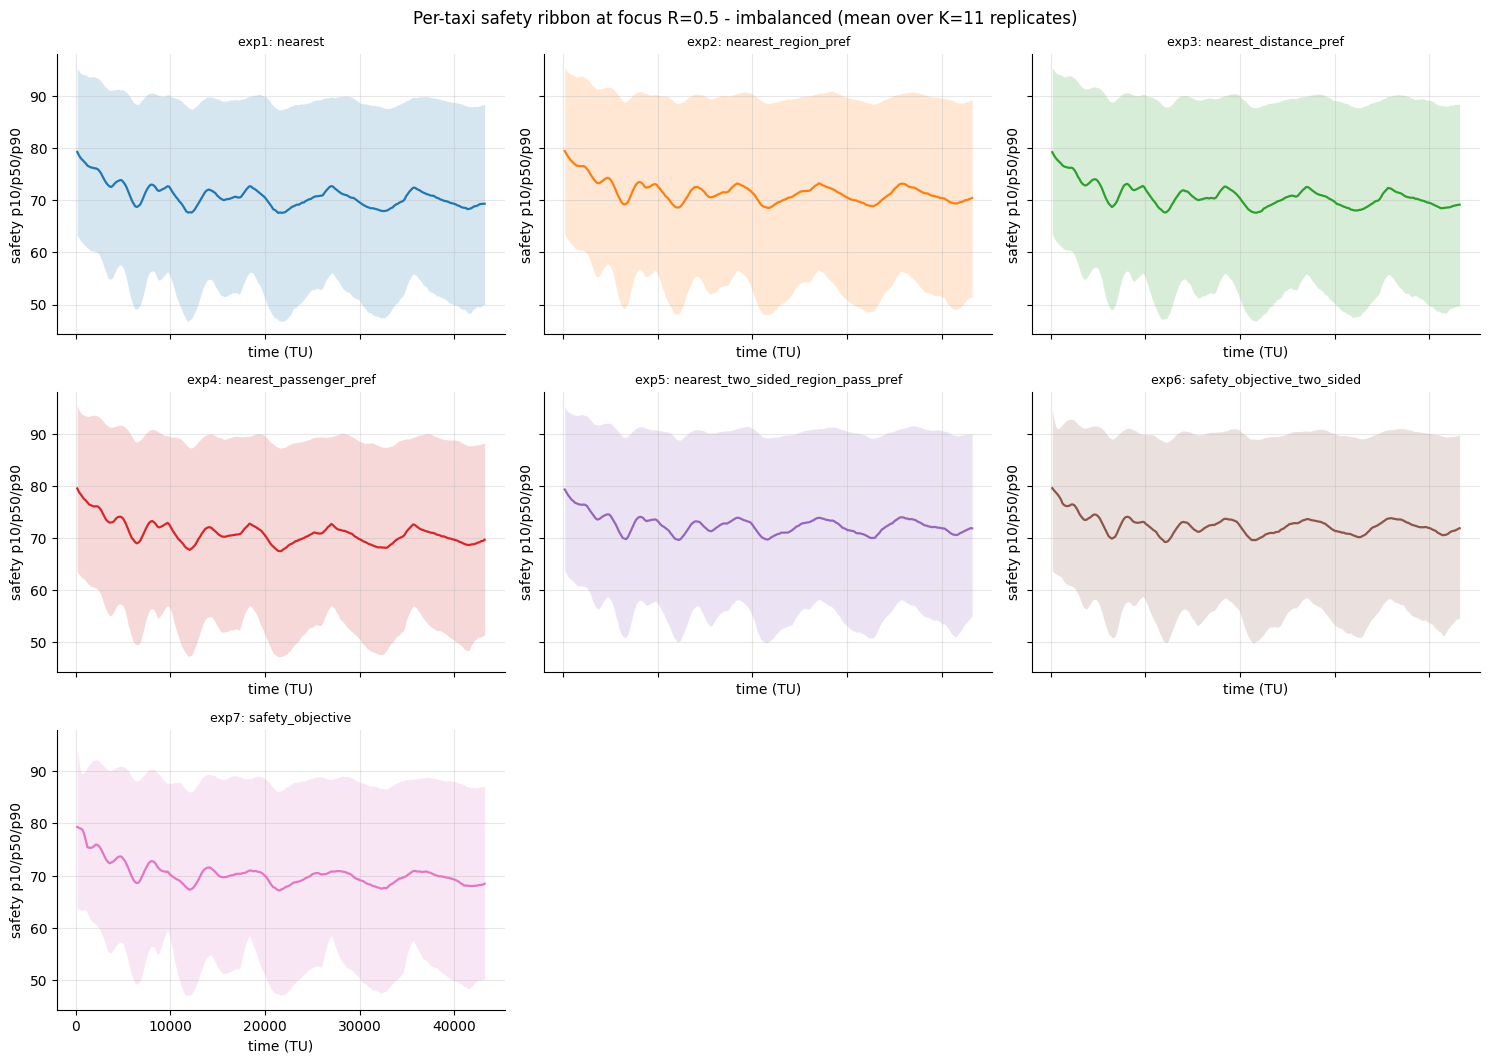

In [7]:
ribbon_exps = EXPERIMENTS
ncol = 3
nrow = int(np.ceil(len(ribbon_exps) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.0 * ncol, 3.6 * nrow),
                         sharex=True, sharey=True, squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)
for e, ax in zip(ribbon_exps, axes.flat):
    ax.set_visible(True)
    sub = focus_runs(fleet, e)
    if sub.empty:
        ax.set_title(f'{EXP_LABEL[e]} (no data)')
        continue
    g = sub.groupby('timestamp')
    p10 = g['safety_p10'].mean()
    p50 = g['safety_p50'].mean()
    p90 = g['safety_p90'].mean()
    ax.plot(p50.index, p50.to_numpy(), color=EXP_COLOR[e], lw=1.6)
    ax.fill_between(p50.index, p10.to_numpy(), p90.to_numpy(),
                    color=EXP_COLOR[e], alpha=0.18, linewidth=0)
    ax.set_title(EXP_LABEL[e], fontsize=12)
    ax.set_xlabel('time (TU)')
    ax.set_ylabel('safety p10/p50/p90')
fig.suptitle(f'Per-taxi safety ribbon at focus R={FOCUS_R} - {GEOMETRY} '
             f'(mean over K=11 replicates)')
plt.tight_layout()
plt.show()

## 5. Per-region safety trajectories

Small multiples by region. In the imbalanced city this exposes the hotspot vs
periphery divergence, where the safety-aware algorithms concentrate or redistribute
service. Only the region-aware algorithms record per-region safety.

In [ ]:
if region.empty:
    print('No per-region safety trajectories for this geometry / experiments.')
else:
    reg_base = _nonrep(region)
    reg_base = reg_base[reg_base['R'] == FOCUS_R]
    region_ids = sorted(region['region_id'].unique())
    reg_exps = sorted(region['experiment'].unique())
    ncol = 3
    nrow = int(np.ceil(len(region_ids) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.2 * nrow),
                             sharex=True, sharey=True, squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for rid, ax in zip(region_ids, axes.flat):
        ax.set_visible(True)
        for e in reg_exps:
            sub = reg_base[(reg_base['experiment'] == e) &
                           (reg_base['region_id'] == rid)]
            if sub.empty:
                continue
            g = sub.groupby('timestamp')['safety_mean'].mean()
            ax.plot(g.index, g.to_numpy(), color=EXP_COLOR.get(e, 'gray'),
                    lw=1.3, label=EXP_LABEL[e])
        ax.set_title(rid, fontsize=12)
        ax.set_xlabel('time (TU)')
        ax.set_ylabel('region safety')
    handles, labels = ax.get_legend_handles_labels()
    fig.suptitle(f'Per-region safety over time at R={FOCUS_R} - {GEOMETRY}')
    fig.tight_layout()
    if handles:
        legend_outside(fig, handles=handles, labels=labels)
    plt.show()

## 6. Shift and break overlay

Break share over time with the fleet mean safety of one algorithm. Vertical
lines mark 8h shift boundaries (reset cohorts re-home), bold lines mark day
boundaries. They line up with the resets and break waves in the safety curves.


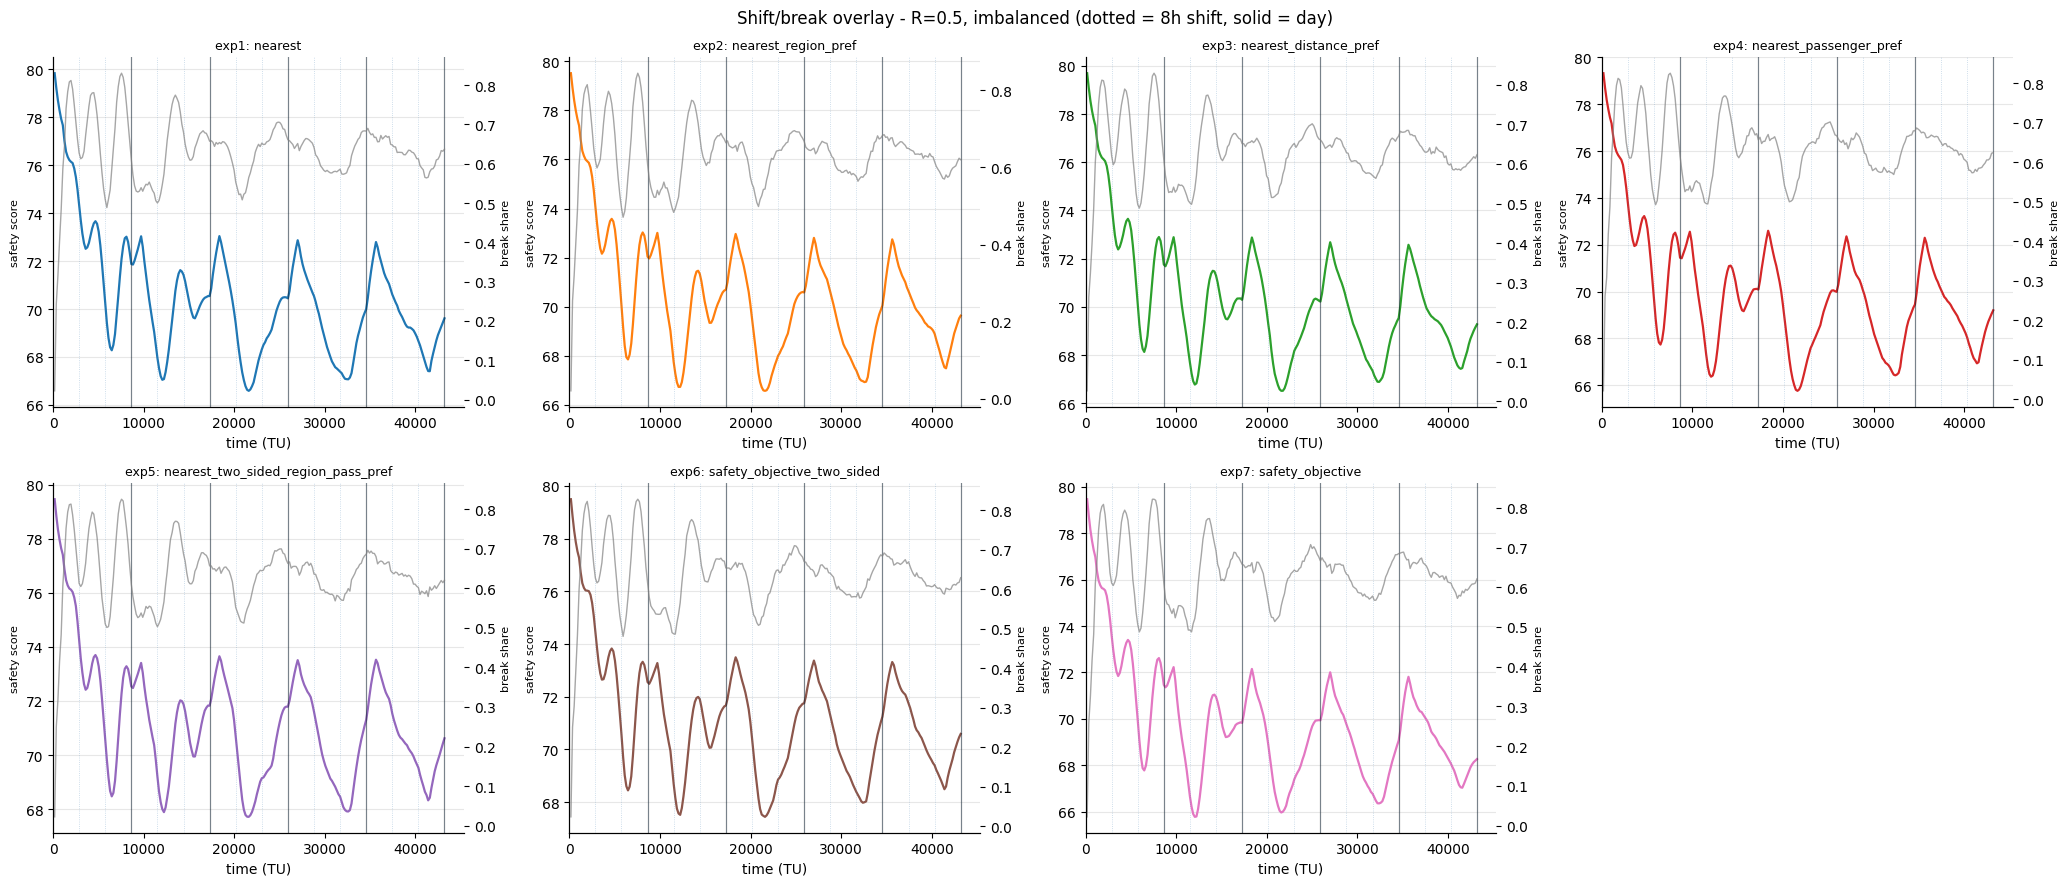

In [22]:
ncols = 4
nrows = int(np.ceil(len(EXPERIMENTS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.5 * nrows), squeeze=False)
tmax = int(fleet['timestamp'].max())

for i, (ax, e) in enumerate(zip(axes.flat, EXPERIMENTS)):
    sub = _nonrep(fleet)
    sub = sub[(sub['experiment'] == e) & (sub['R'] == FOCUS_R)]
    if sub.empty:
        ax.set_title(f'{EXP_LABEL[e]} (no data)', fontsize=12)
        continue
    saf = sub.groupby('timestamp')['safety_mean'].mean()
    brk = sub.groupby('timestamp')['break_share'].mean()

    ax.plot(saf.index, saf.to_numpy(), color=EXP_COLOR[e], lw=1.6)
    ax.set_xlabel('time (TU)')
    ax.set_ylabel('safety score', fontsize=12)
    ax.xaxis.grid(False)
    ax.set_xlim(left=0)

    ax2 = ax.twinx()
    ax2.plot(brk.index, brk.to_numpy(), color='gray', lw=1.0, alpha=0.7)
    ax2.set_ylabel('break share', fontsize=12)
    ax2.grid(False)

    for x in range(SHIFT_TU, tmax + 1, SHIFT_TU):
        ax.axvline(x, color='steelblue', lw=0.6, alpha=0.35,
                   ls=':' if x % DAY_TU else '-')
    for x in range(DAY_TU, tmax + 1, DAY_TU):
        ax.axvline(x, color='black', lw=0.9, alpha=0.4)

    ax.set_title(EXP_LABEL[e], fontsize=12)

for ax in list(axes.flat)[len(EXPERIMENTS):]:
    ax.set_visible(False)

fig.suptitle(f'Shift/break overlay - R={FOCUS_R}, {GEOMETRY} '
             f'(dotted = 8h shift, solid = day)')
plt.tight_layout()
plt.show()